In [1]:
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
def get_hist_df_dataframe(filename):
    file = uproot.open(filename)
    tree = file["hist_df"]

    df = tree.arrays(library="pd")

    # -----------------------------
    # 2. Convert ROOT format → hist_df format
    # -----------------------------
    hist_df = pd.DataFrame({
        1: df["ge_1"],
        2: df["ge_2"],
        3: df["ge_3"],
        4: df["ge_4"],
        5: df["ge_5"],
        6: df["ge_6"],
        7: df["ge_7"],
        8: df["ge_8"],
    })

    # use Ring as index (same as pandas version)
    hist_df.index = df["Ring"]
    hist_df = hist_df.sort_index()

    return hist_df
    

In [2]:
!ls

18_Feb_2026    4_march_2026		       ring_maping.pdf
28_April_2026  creating_plots_histogram.ipynb  save_to_paraquet.ipynb


In [3]:
from IPython.display import IFrame

IFrame("ring_maping.pdf", width=800, height=600)

In [3]:
! ls ../Histogram_files/28_April_2026/Background_Data

hist_Counts_50000_5min_10ns_csv_grouping2.root
hist_Counts_50000_5min_10ns_csv.root
hist_Counts_50000_5min_2ns_csv_grouping2.root


In [4]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh230_5min = get_hist_df_dataframe("../Histogram_files/28_April_2026/Background_Data/hist_Counts_50000_5min_10ns_csv.root")

print(hist_df_Thresh230_5min)

            1        2        3       4       5       6       7       8
Ring                                                                   
1     5079115   571598   294506   51391    2149     313     240     185
2     4734104  1128594   650126  393329   35764    2061     321     167
3     2519441   680756   563679  501909  443369  384929  319509  222621
4     2795018   973558   648349  374959  215870  128114   30305     915
5           0        0        0       0       0       0       0       0
6     3017703  1143348   838182  715343  586661  394309  313373  240831
7     3196450   240938   132693   40376    4744     601     329     247
8     4917311    63385     2786     804      53      14       5       1
9     3444148    34434     1748     845      50      31      22      15
10    2552424    39741     6664    2321     390     108      37      11
11    5948332   239510   113904   62273   17883    4014     998     297
12    1729981     8083      994     693      36      20       9 

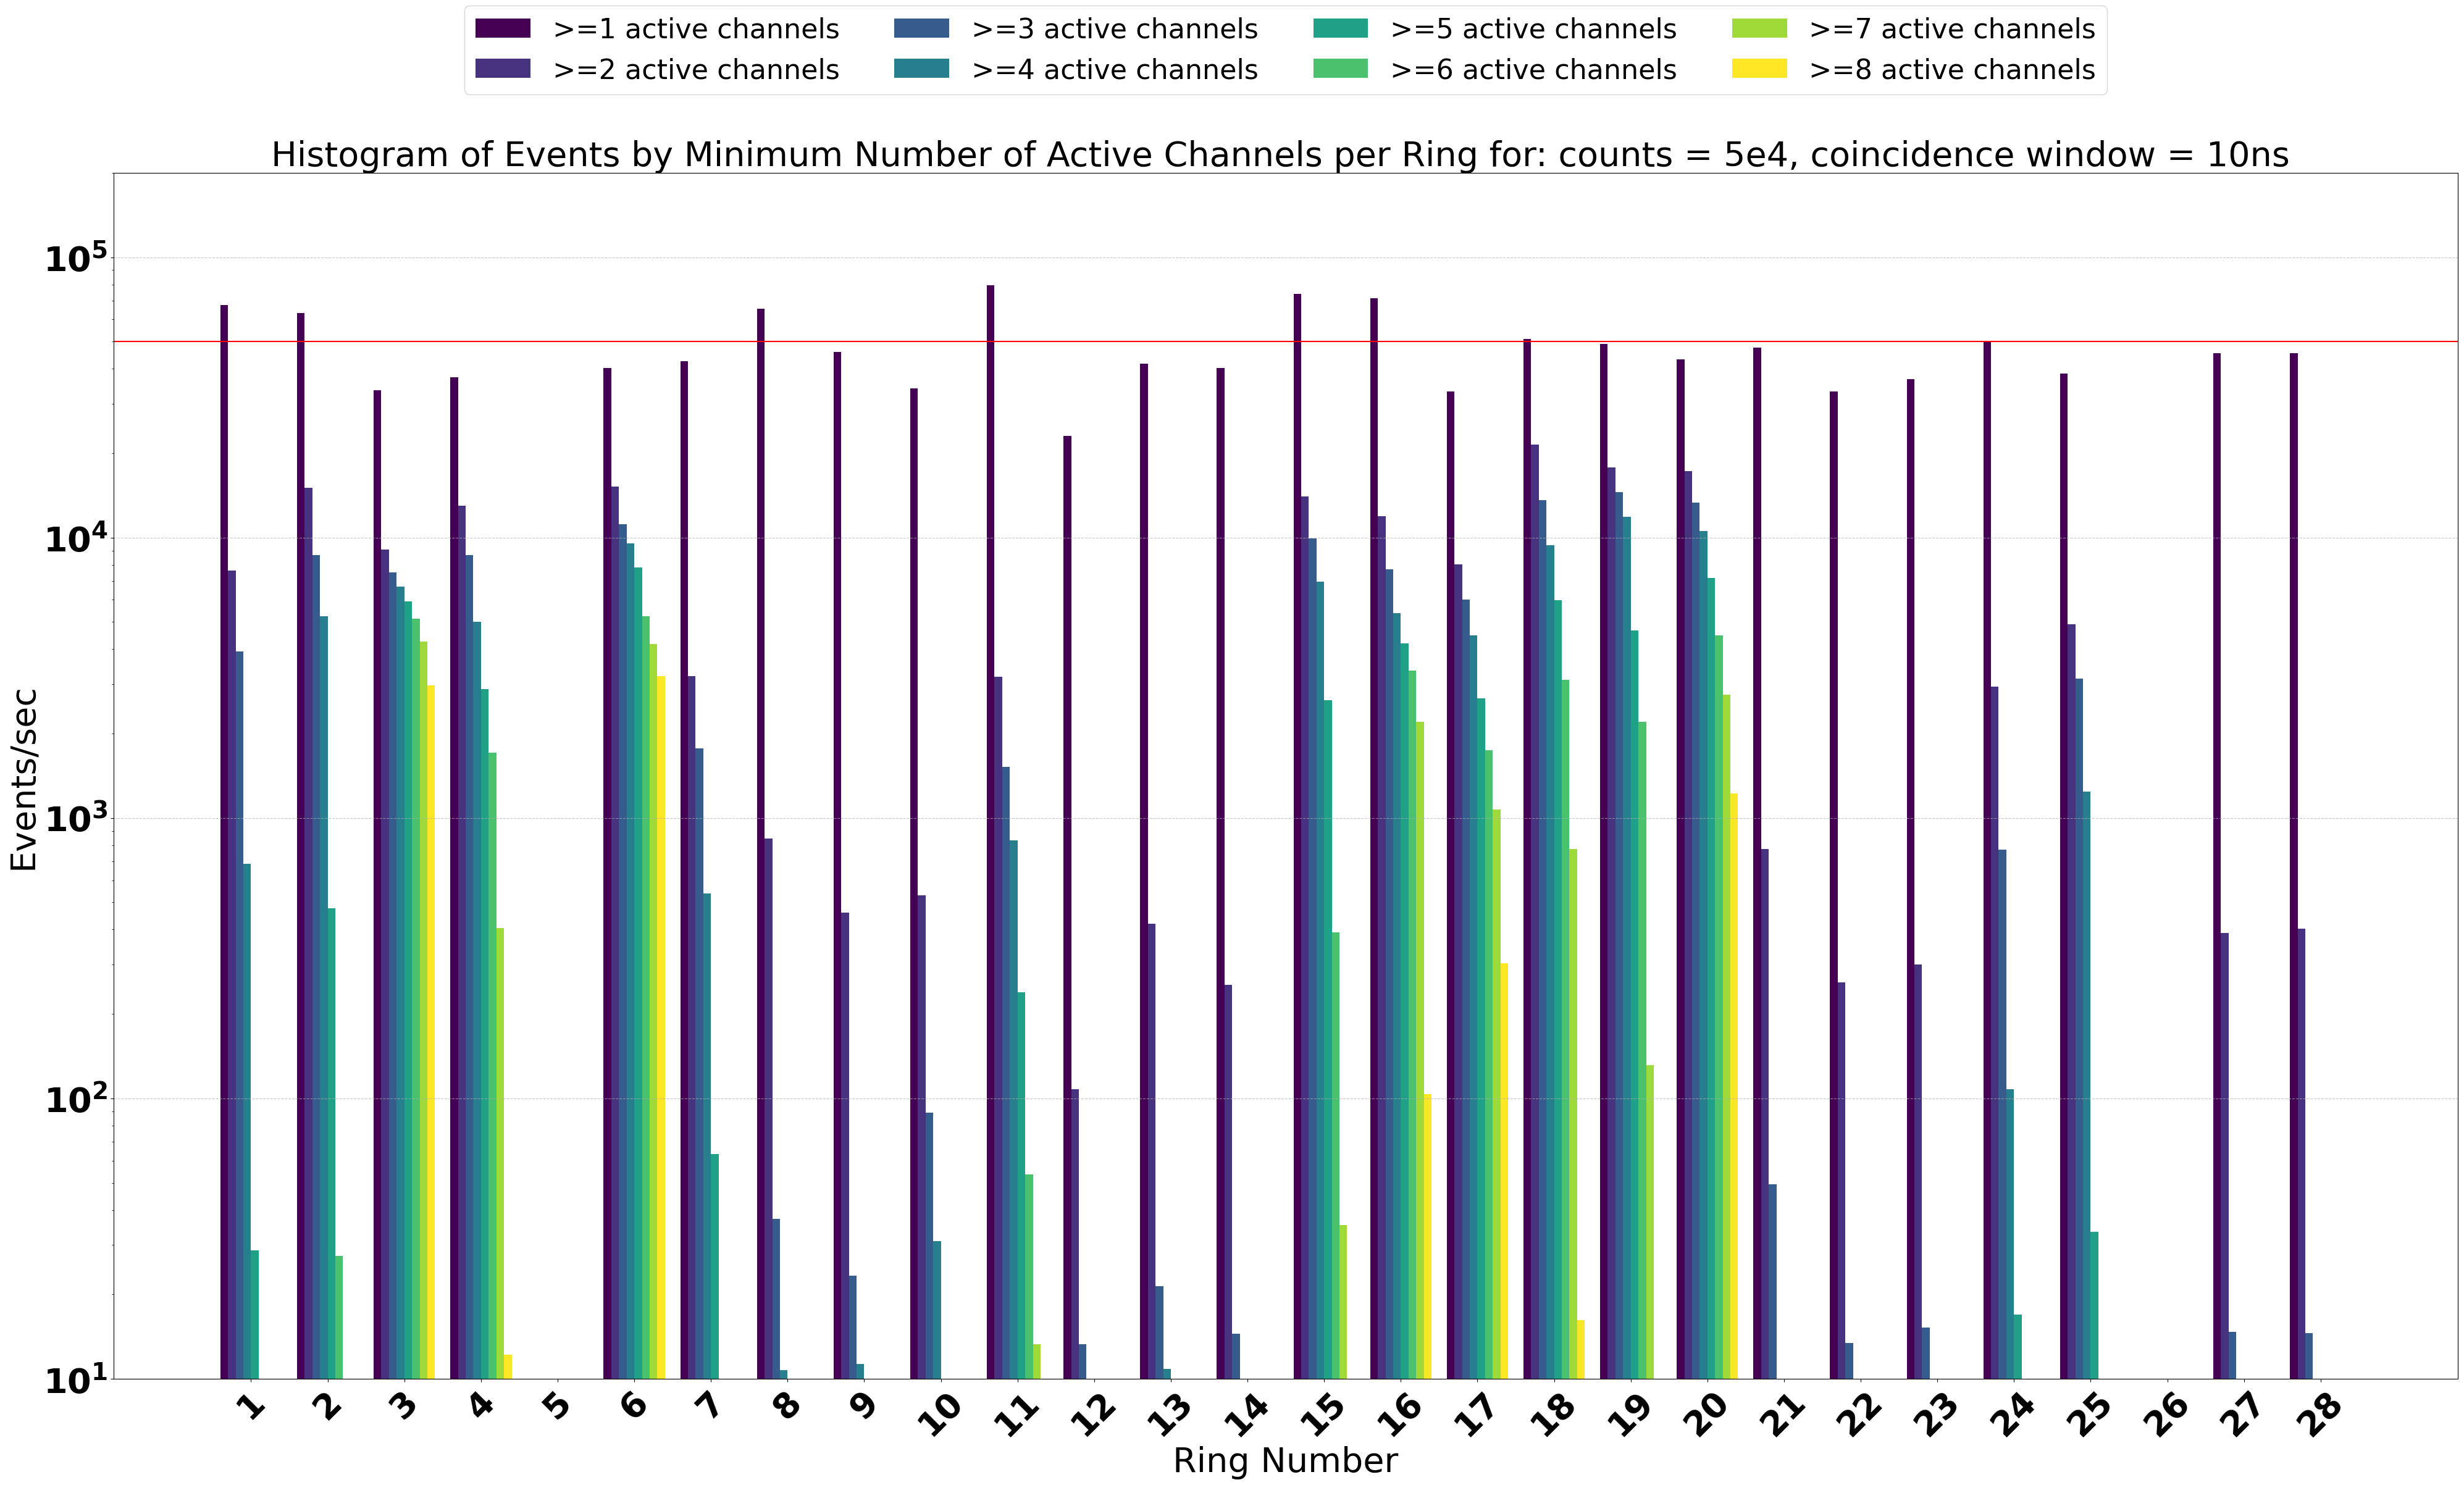

In [6]:

# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh230_5min.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh230_5min[x_thr]/75,
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Events/sec', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for: counts = 5e4, coincidence window = 10ns ', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 2e5)  # adjust if needed
plt.axhline(y=5e4, color='red')
plt.yscale("log")
plt.tight_layout()
plt.show()

In [9]:
!ls ../Histogram_files/28_April_2026/SourceOnRing10

hist_Counts_50000_5min_10ns_csv_grouping2.root
hist_Counts_50000_5min_10ns_csv.root


In [11]:
# -----------------------------
# 1. Read ROOT file hist_Counts_50000_5min_10ns_csv.root
# -----------------------------
hist_df_Thresh260_5min =  get_hist_df_dataframe(" ../Histogram_files/28_April_2026/SourceOnRing10/hist_Counts_50000_5min_10ns_csv.root")

print(hist_df_Thresh260_5min)

            1        2        3        4       5       6       7       8
Ring                                                                    
1     3484869   892380   568705    59076    2191     515     372     289
2     4532163  1894668  1031342   614002   62721    5377     713     336
3     2328565  1059870   898084   772185  656663  536747  428561  267848
4     3702834  1873401  1084639   826178  518635  345517  104658    1460
5           0        0        0        0       0       0       0       0
6     3372833  1678263  1284462  1107751  936616  666200  478236  330853
7     3291943   407879   207570    30129    3044    1253    1035     850
8     1892279    50331     8162     2673     109      39      22      11
9     1431587    34946     7043     3838     173      87      48      22
10    2099238   106223    35822    16032    2524     546     124      34
11    2443457   243121   190525   138944   73815   29612    4335    1636
12     394985    12289     6122     4991     105   

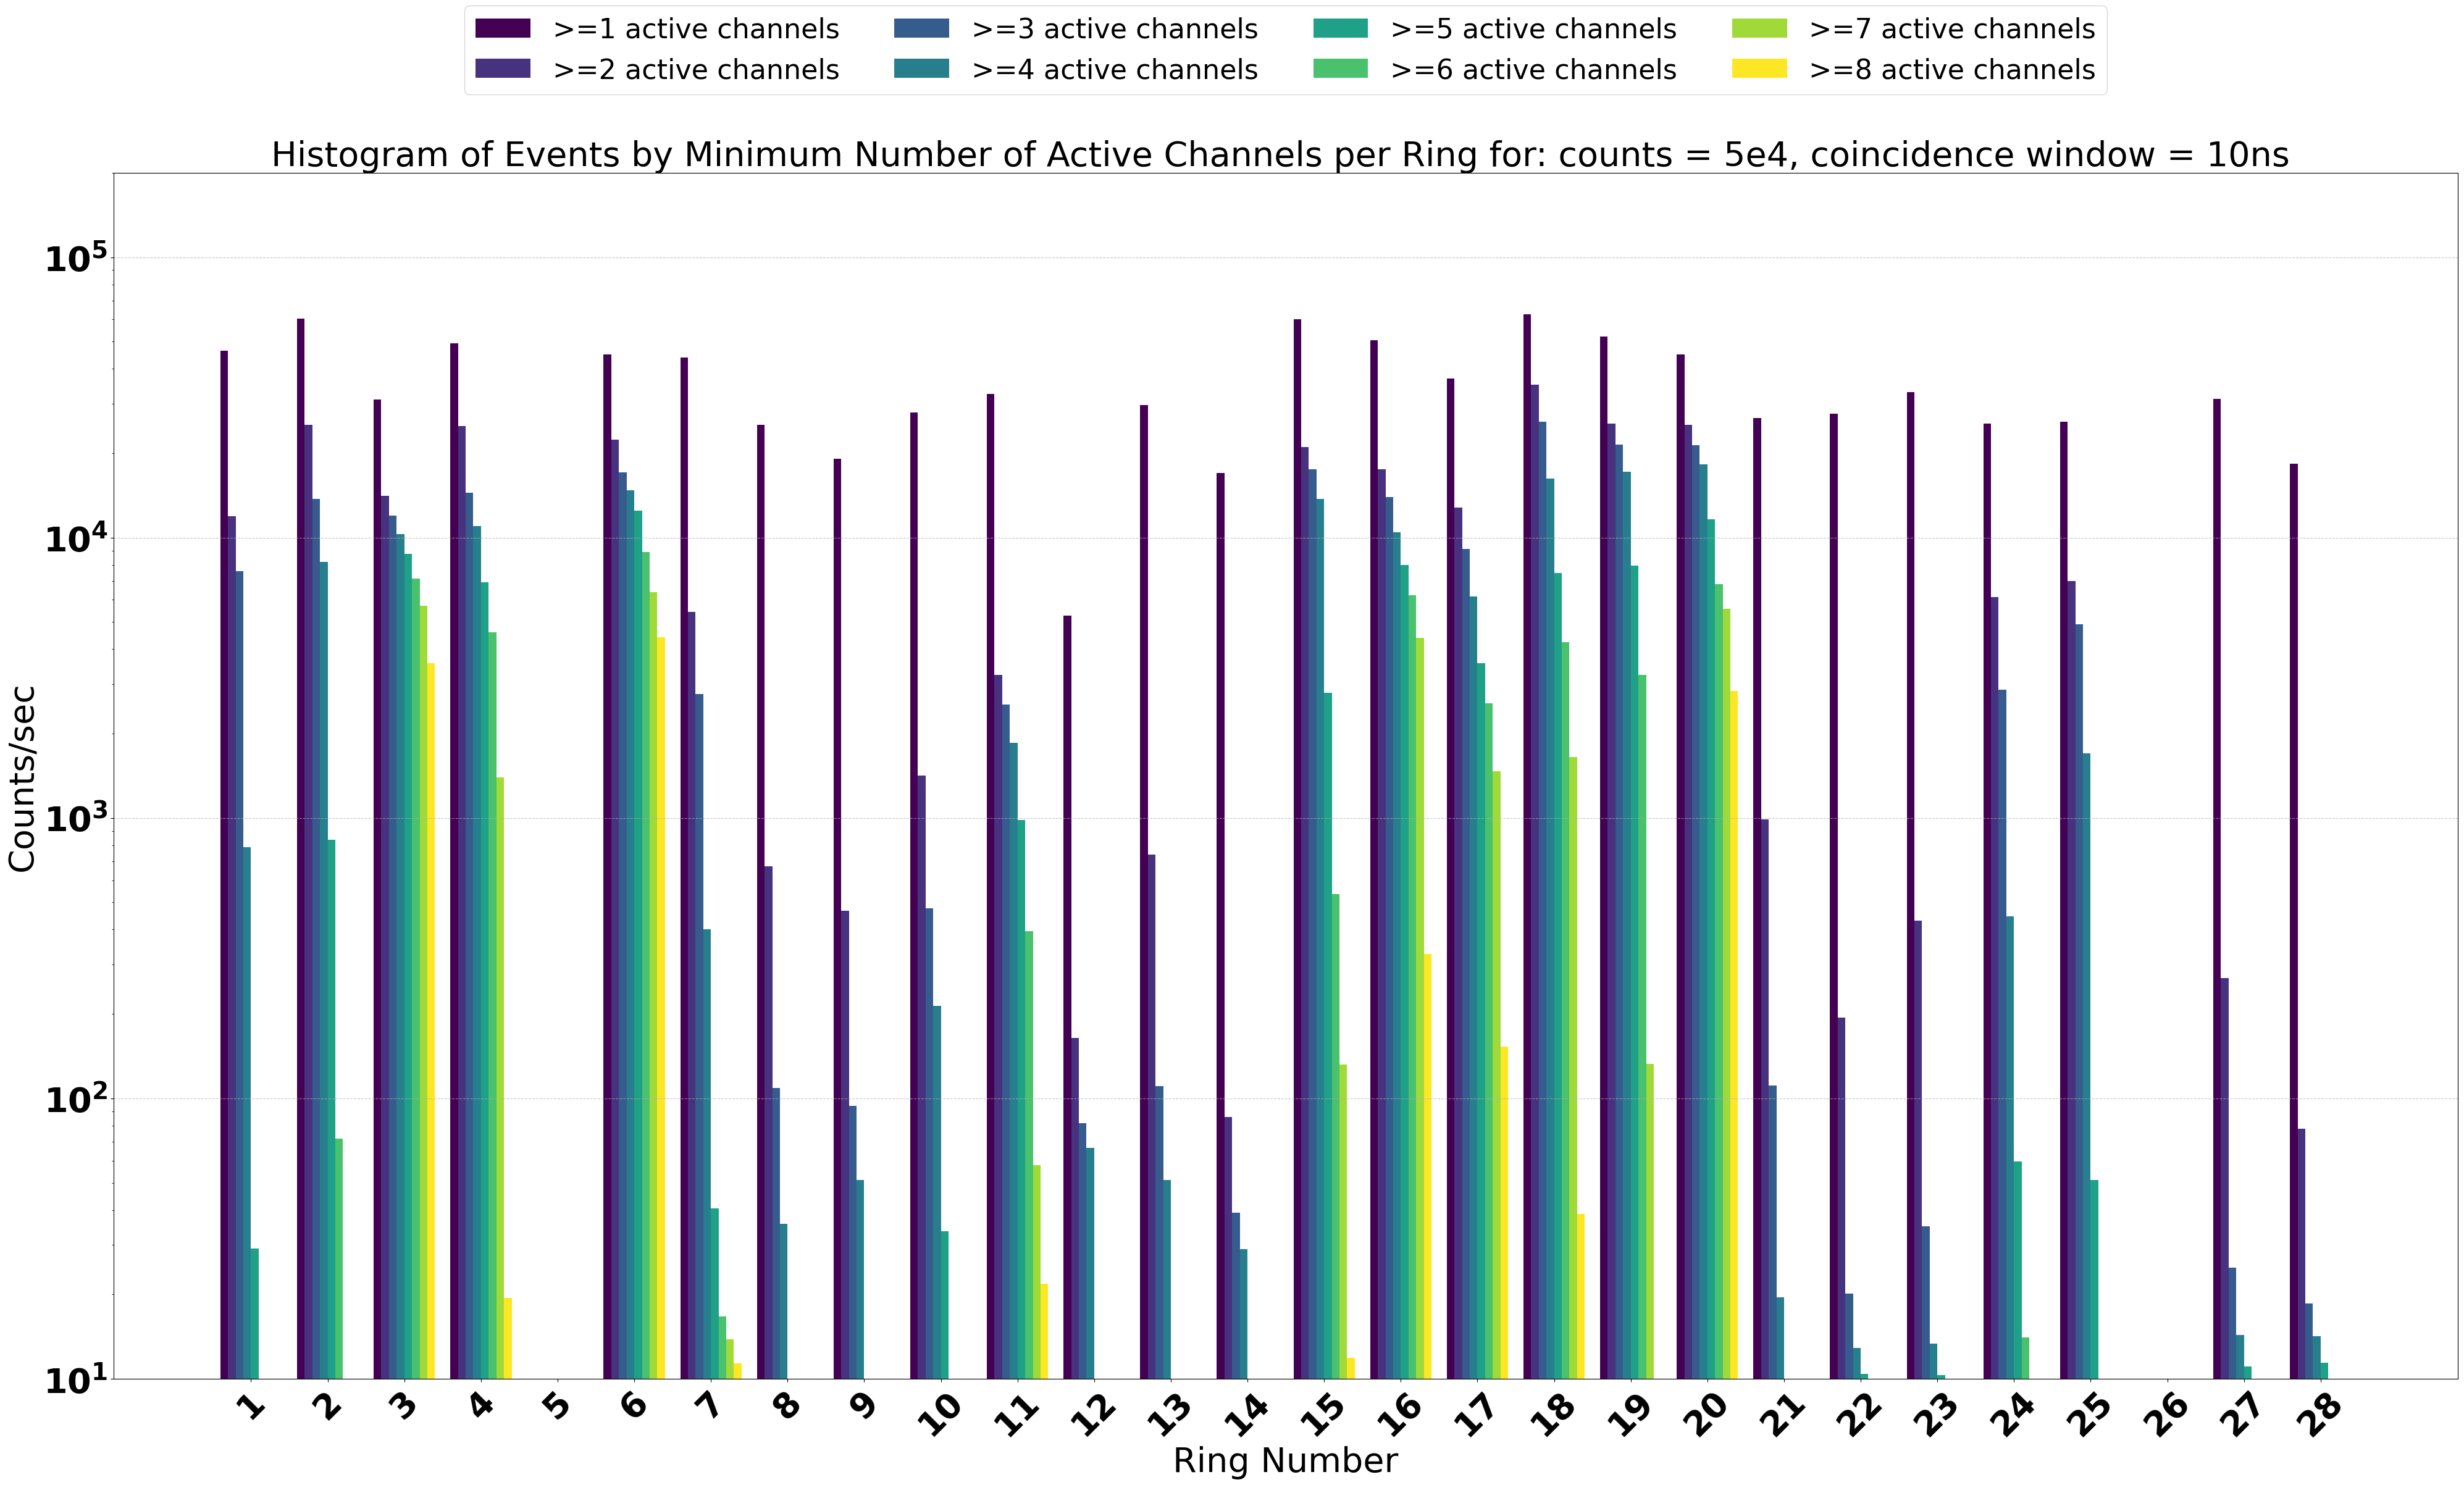

In [12]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh260_5min.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh260_5min[x_thr]/75.0,
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Counts/sec', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for: counts = 5e4, coincidence window = 10ns ', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.15), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 2e5)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()

In [3]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh260_5min_10ns = get_hist_df_dataframe("../Histogram_files/4_March_2026/hist_df_Thresh260-5min_10ns_grouping2.root")

print(hist_df_Thresh260_5min_10ns)

            1        2        3       4       5       6       7     8
Ring                                                                 
1      507584     1994     1068     946     870     792     717   608
2     1192034   397284   304865   58691    8608    1745     840   634
3     2247575  1275476  1043265  886712  656532  365457  125657  4824
4     1480004   507255    60820    4451    1282    1097     968   816
5     2718977  1998649   680491  154325   19273    2149    1040   842
6     1429140   267344    69812   15236    4736    2099    1320   938
7      859722    59143    20737    5121    2154    1510    1126   918
8     1362095     8070     3178    2417      74      48      36    27
9      389569     5372     3205    2485     122     104      80    61
10     489576     6814     3171    2404     165     125      98    77
11    3337772   511199   389602  267423  141095   30347    5069  1646
12     340151     4391     2867    2237     118      94      67    49
13    1829480     87

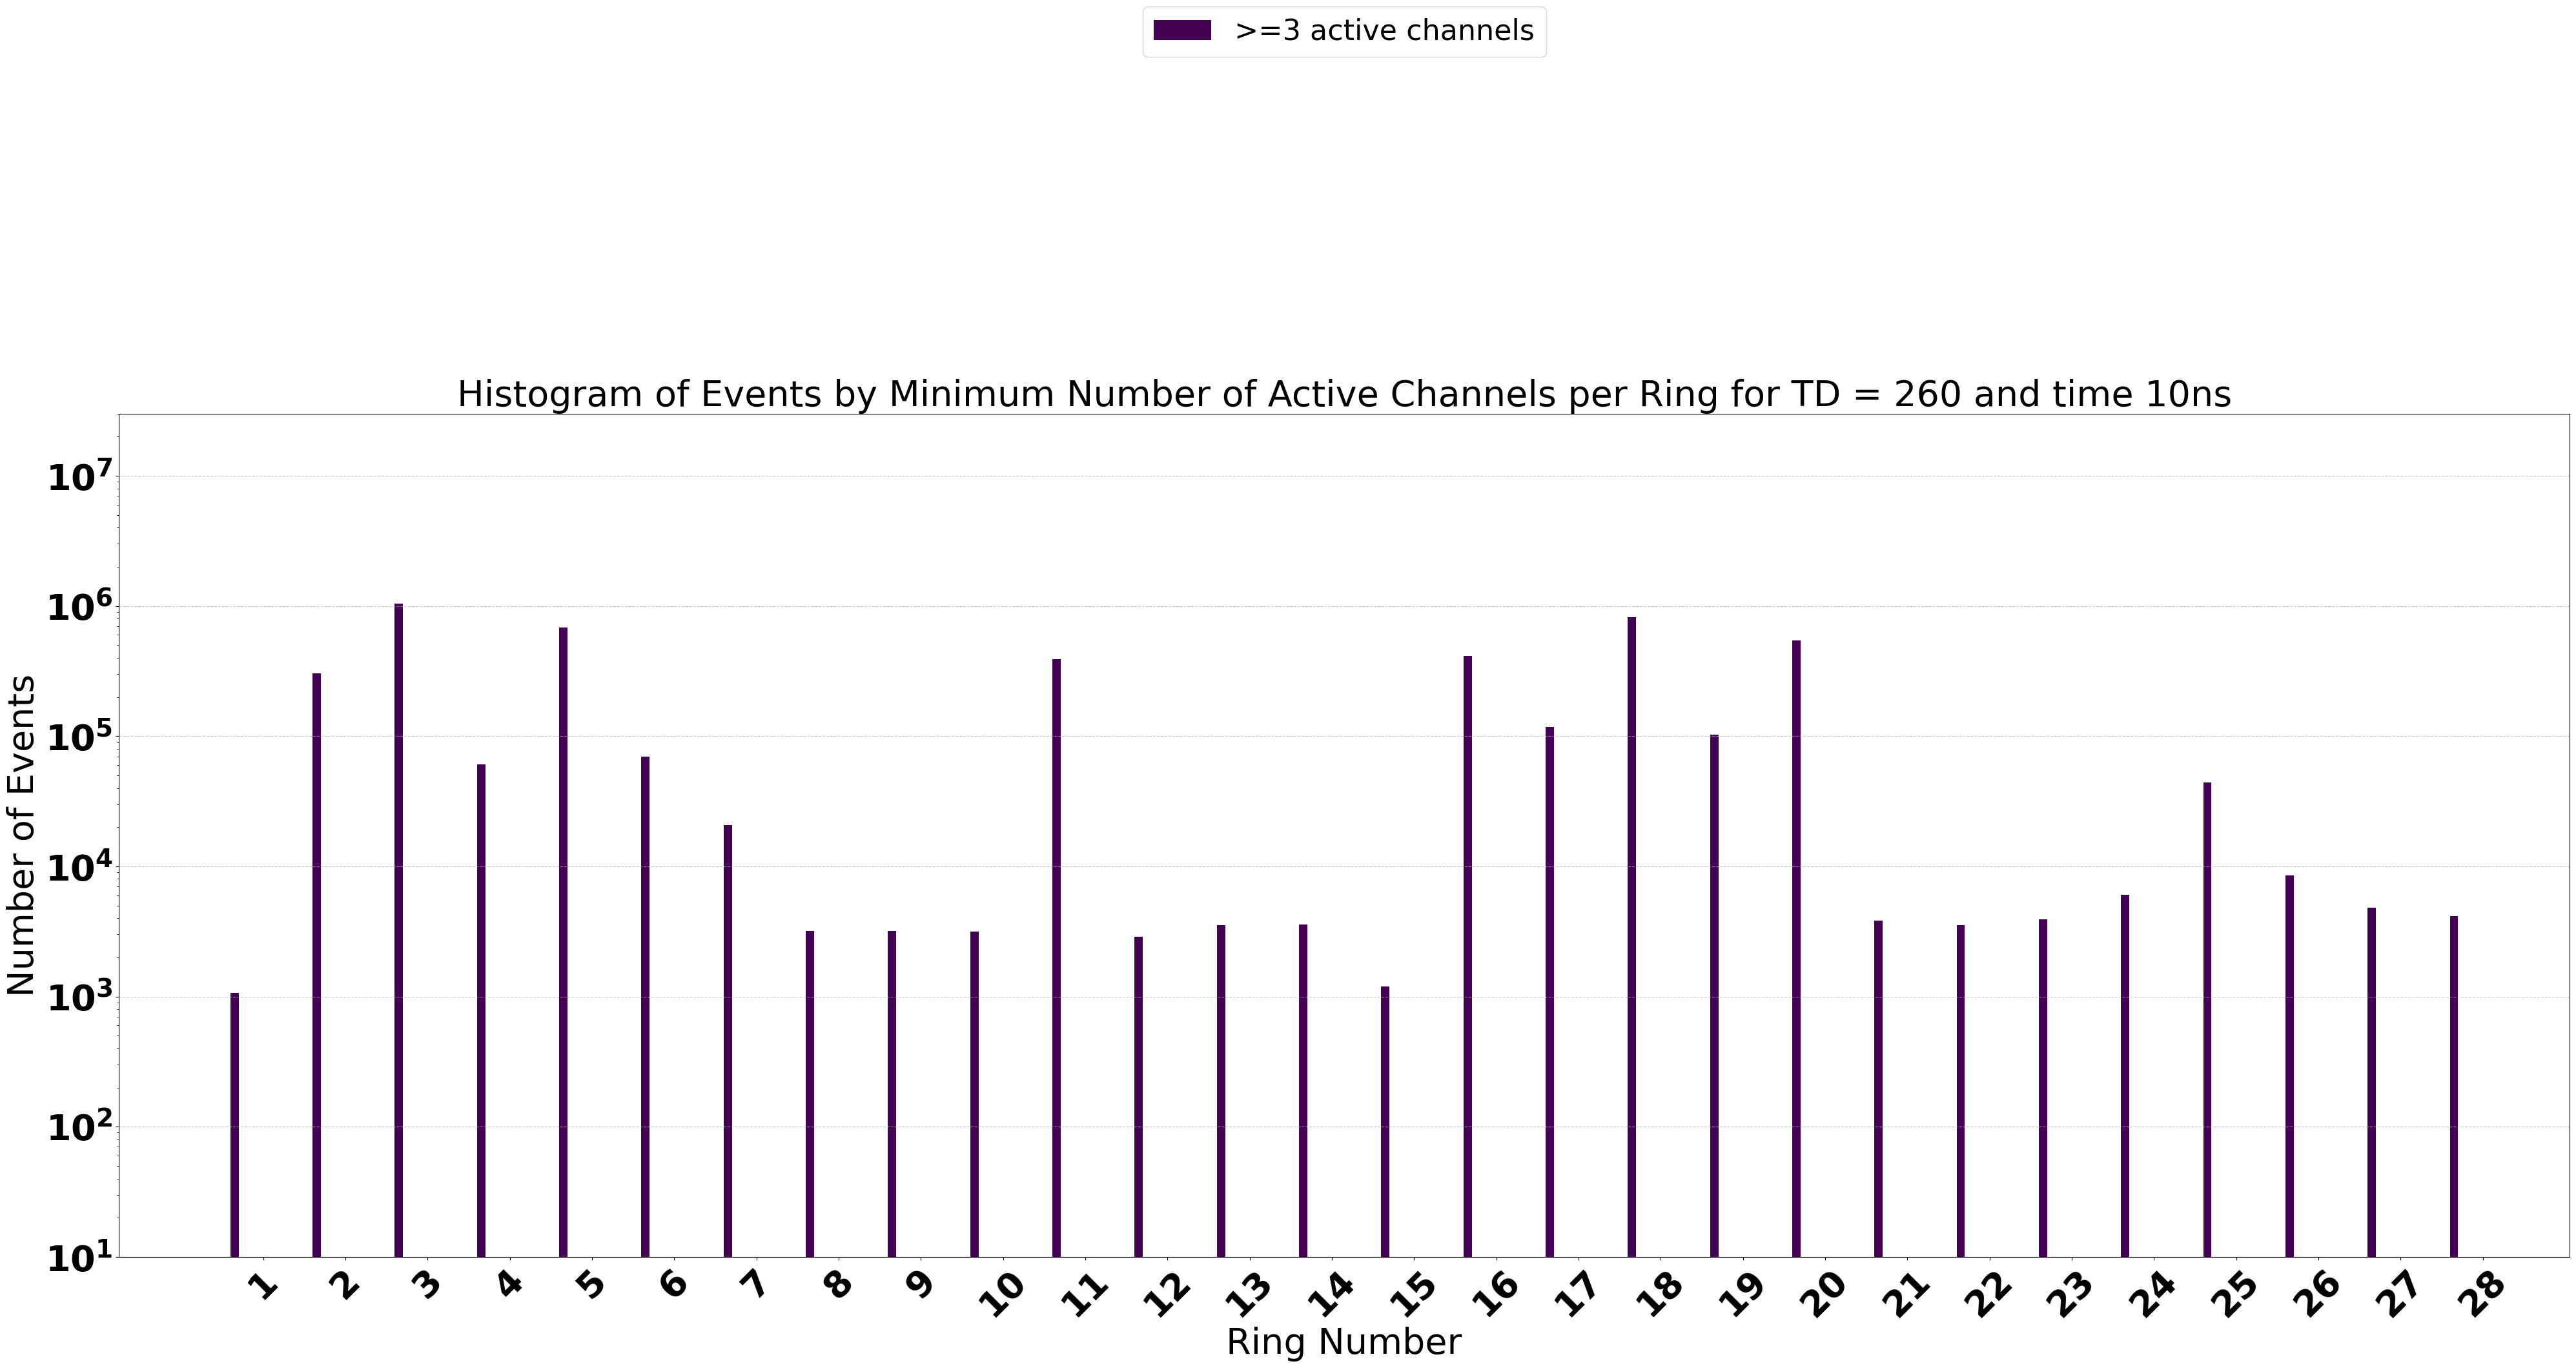

In [8]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh260_5min_10ns.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(40, 24))
for i, x_thr in enumerate(range(3, 4)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh260_5min_10ns[x_thr],
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Number of Events', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for TD = 260 and time 10ns', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.5), # Position above plot
    title_fontsize=23       # Slightly larger title
)
plt.ylim(10, 3e7)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()

In [37]:
# -----------------------------
# 1. Read ROOT file
# -----------------------------
hist_df_Thresh200_5min_10ns = get_hist_df_dataframe("../ROOT_files/Thresh200-5min/hist_df_10ns.root")

print(hist_df_Thresh200_5min_10ns)

            1       2      3      4     5     6     7     8
Ring                                                       
1     6164718  513678  53498   9688  3794  2529  1622   719
2     5713376  462751  69070  21483  9022  4713  2430  1016
3     3479316  349371  50708   9628  2268   674   198    44
4     2665783  142662   8574    529    87    50    32    14
5     2345664  116546   6776    400    77    43    25    10
6     3481504  311961  55255  14980  2978   711   185    46
7     3327078  307731  60956  16556  3257   583    86    19
8     2423296  109236   5635    339    73    39    17     8
9     2706106  112512   5662    394    92    47    28    14
10    3256201  178579  20193   4670  1230   373   132    39
11    3158429  263603  43798  10268  2475   693   185    34
12    2861113  217986  21211   2987   681   201    57    15
13    2423788  114590   6355    345    40    20     9     5
14    2863527  122613   6504    371    51    22    13     5
15    6839887  473654  41489   6343  149

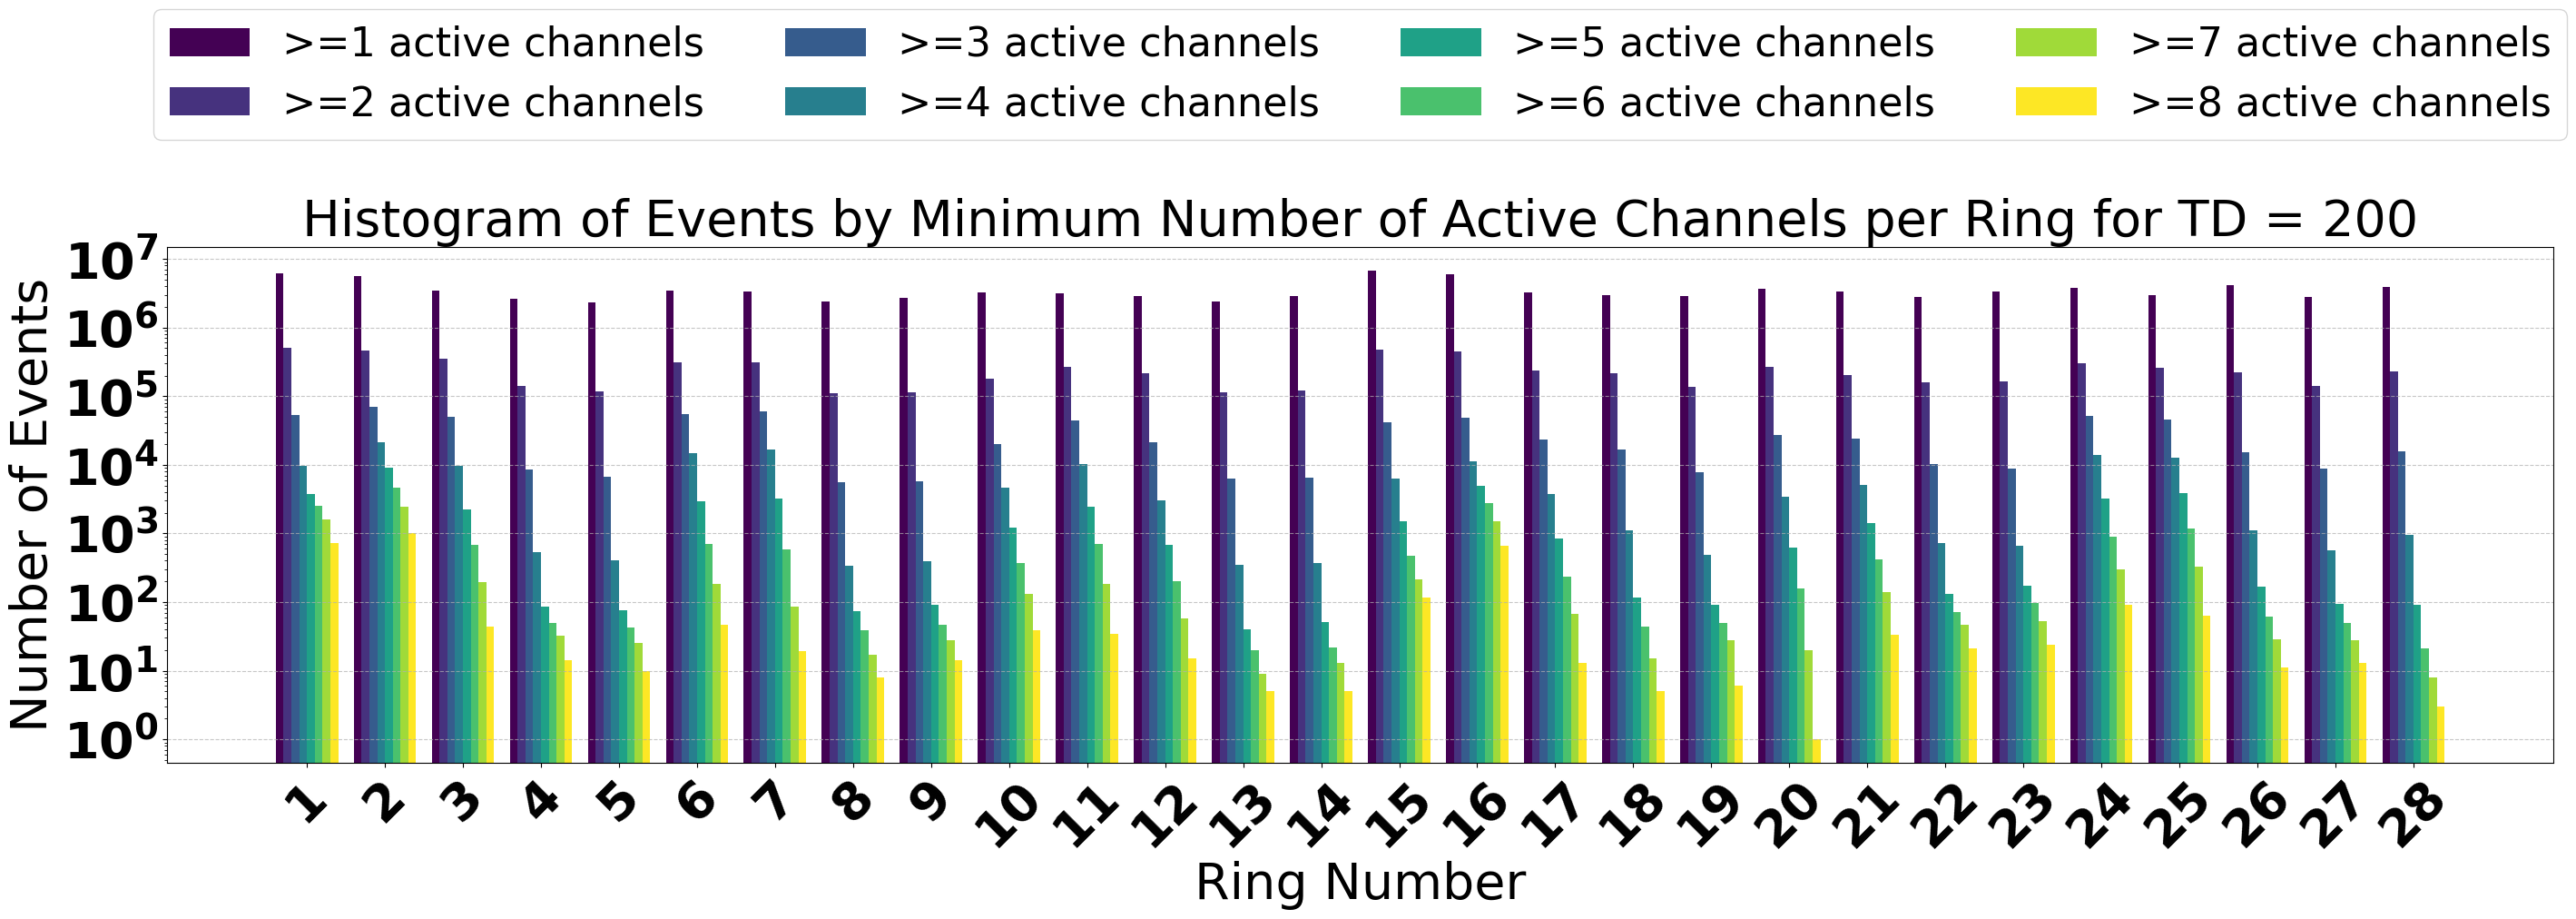

In [40]:
# ----------------------------- # Plot 2: Events vs min # active channels per ring # -----------------------------
rings = hist_df_Thresh200_5min_10ns.index
n_rings = len(rings)
x_indices = np.arange(n_rings)
bar_width = 0.1
colors = plt.cm.viridis(np.linspace(0, 1, 8))

plt.figure(figsize=(30, 12))
for i, x_thr in enumerate(range(1, 9)):
    bar_positions = x_indices + i * bar_width
    plt.bar(bar_positions, hist_df_Thresh200_5min_10ns[x_thr],
            width=bar_width, color=colors[i],
            label=f'>={x_thr} active channels')

tick_positions = x_indices + 3.5 * bar_width
plt.xticks(tick_positions, rings, fontsize=40, fontweight='bold', rotation=45)
plt.xlabel('Ring Number', fontsize=40)
plt.ylabel('Number of Events', fontsize=40)
plt.title('Histogram of Events by Minimum Number of Active Channels per Ring for TD = 200', fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=40, fontweight='bold')
# Legend customization
plt.legend(
    fontsize=32,
    ncol=4,                 # 4 columns (2x4 structure)
    loc='upper center',     # Anchor location
    bbox_to_anchor=(0.5, 1.5), # Position above plot
    title_fontsize=23       # Slightly larger title
)
#plt.ylim(1000, 4e5)  # adjust if needed
plt.yscale("log")
plt.tight_layout()
plt.show()